In [102]:
!pip install opendatasets

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import opendatasets as od
import tensorflow as tf

In [104]:
od.download("https://www.kaggle.com/datasets/saranpannasuriyaporn/male-female-height-and-weight")

Skipping, found downloaded files in "./male-female-height-and-weight" (use force=True to force download)


In [105]:
data = pd.read_csv("/content/male-female-height-and-weight/Test set.csv")

In [106]:
data.head()

,Height,Weight,Sex
0,146.323241,59.861065,Female
1,175.695412,77.863687,Male
2,183.216164,72.131992,Male
3,184.245269,77.546000,Male
4,132.302261,55.188496,Female


In [107]:
# change sex cloumn into numeric value
data['Sex'] = data['Sex'].map({'Male': 1, 'Female': 0})


In [108]:
data.head()


,Height,Weight,Sex
0,146.323241,59.861065,0
1,175.695412,77.863687,1
2,183.216164,72.131992,1
3,184.245269,77.546000,1
4,132.302261,55.188496,0


In [109]:
x = data.drop(['Sex'],axis=1)
y = data['Sex']

In [110]:
x.head()

,Height,Weight
0,146.323241,59.861065
1,175.695412,77.863687
2,183.216164,72.131992
3,184.245269,77.546000
4,132.302261,55.188496


In [111]:
y.head()

,Sex
0,0
1,1
2,1
3,1
4,0


In [112]:
# feature scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)
x = pd.DataFrame(x_scaled, columns=['Height', 'Weight'])

In [113]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  205 non-null    float64
 1   Weight  205 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [114]:
y[:5]

,Sex
0,0
1,1
2,1
3,1
4,0


In [115]:
y.dtype

dtype('int64')

In [116]:
y = y.astype('int')

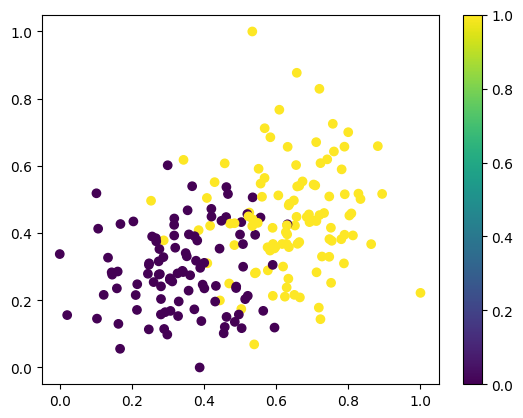

In [117]:
plt.scatter(x['Height'],x['Weight'],c=y)
plt.colorbar()
plt.show()

In [118]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [119]:
x_train.shape, x_test.shape

((164, 2), (41, 2))

In [120]:
data.shape

(205, 3)

# model building

In [121]:
# # create model
# model = tf.keras.Sequential([
#     tf.keras.layers.Dense(4, activation= 'relu', input_shape=(2,)),
#     tf.keras.layers.Dense(1, activation= 'sigmoid')
#     ])
# # compile model
# model.compile(loss= tf.keras.losses.BinaryCrossentropy(),
# optimizer= tf.keras.optimizers.Adam(learning_rate = 0.01),
# metrics= ['accuracy'])

# # train model
# model.fit(x_train, y_train, epochs= 5)

# # evaluate model
# model.evaluate(x_test, y_test)

In [122]:
# model.summary()


In [123]:
# y_pred = model.predict(x_test)
# y_pred[:5]

In [124]:
# y_pred[:5]

In [125]:
# y_test[:5]

# OPTION 2

In [126]:
# create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(2, activation='sigmoid')
])

# compile the model
model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
             optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
             metrics = ["accuracy"])

# train the model
epoch_number = 20
history = model.fit(x_train, y_train, epochs=epoch_number)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 441ms/step - accuracy: 0.4789 - loss: 0.6804
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7277 - loss: 0.5959
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7024 - loss: 0.5367
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8250 - loss: 0.3976 
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8120 - loss: 0.3828 
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8775 - loss: 0.2748
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8792 - loss: 0.2668
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8303 - loss: 0.3301
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8199 - loss: 0.3780
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8501 - loss: 0.3029
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8056 - loss: 0.4228
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8595 - loss: 0.3250 
Epoch 13

In [127]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,144 (113.85 KB)

 Trainable params: 9,714 (37.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,430 (75.90 KB)

# model evaluate

In [128]:
model.evaluate(x_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 346ms/step - accuracy: 0.9141 - loss: 0.2458


[0.26065176725387573, 0.9024389982223511]

In [129]:
y_pred = model.predict(x_test)
y_pred[:5]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


array([[0.6264112 , 0.17663386],
       [0.1276722 , 0.8937471 ],
       [0.08698067, 0.9328462 ],
       [0.57600904, 0.2618634 ],
       [0.14395759, 0.85470366]], dtype=float32)

In [130]:
import numpy as np
y_pred = np.argmax(y_pred, axis=1)
y_pred[:5]

array([0, 1, 1, 0, 1])

In [131]:
y_test[:5]

,Sex
15,0
9,1
100,1
132,0
68,1


In [132]:
# precision
precision = tf.keras.metrics.Precision()
precision.update_state(y_test, y_pred)
precision.result()



<tf.Tensor: shape=(), dtype=float32, numpy=0.8636363744735718>

In [133]:
# recall
recall = tf. keras.metrics.Recall()
recall.update_state(y_test, y_pred)
recall.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.949999988079071>

<Axes: >

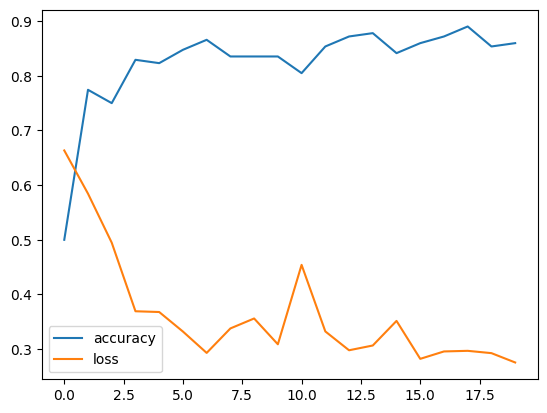

In [134]:
pd.DataFrame(history.history).plot()